In [231]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "rescomp", "rescomp")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Thinned_Rescomp", "utils")))
import ResComp
from helper import get_orbit, create_network
from metrics import vpt_time
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import scipy as sp
from scipy import optimize
from pathlib import Path

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}",
    "font.family": "serif",
    'font.sans-serif': ['Computer Modern Roman'],
    'font.serif': ['Computer Modern Roman'],
    'font.size': 16
})

### Compute and Save High VPT Matrices

In [232]:
def get_dir_path(
    n,
    network_type,
    rho,
    mean_degree,
    alpha,
    gamma,
    sigma,
    tol,
    duration,
    switch  
):
    return Path(f'data/n_{n}_n_type_{network_type}_rho_{rho}_mean_degree_{mean_degree}_alpha_{alpha}_gamma_{gamma}_sigma_{sigma}_tol_{tol}_duration_{duration}_switch_{switch}/')

In [233]:
def load_data(n, network_type, rho, mean_degree, alpha, gamma, sigma, tol, duration, switch):
    directory_path = get_dir_path(n, network_type, rho, mean_degree, alpha, gamma, sigma, tol, duration, switch)
    A = np.load(directory_path / Path("A.npy"))
    r0 = np.load(directory_path / Path("r0.npy"))
    vpt = np.load(directory_path / Path("vpt.npy"))
    t_train = np.load(directory_path / Path("t_train.npy"))
    U_train = np.load(directory_path / Path("U_train.npy"))
    t_test = np.load(directory_path / Path("t_test.npy"))
    U_test = np.load(directory_path / Path("U_test.npy"))
    U_hat_train = np.load(directory_path / Path("U_hat_train.npy"))
    U_hat_pred = np.load(directory_path / Path("U_hat_pred.npy"))
    states_train = np.load(directory_path / Path("states_train.npy"))
    states_pred = np.load(directory_path / Path("states_pred.npy"))
    W_out = np.load(directory_path / Path("W_out.npy"))
    return A, r0, t_train, U_train, t_test, U_test, U_hat_train, U_hat_pred, states_train, states_pred, W_out, vpt

In [234]:
def find_reservoir(
    n,
    network_type,
    rho,
    mean_degree,
    alpha,
    gamma,
    sigma,
    tol,
    duration,
    switch
):
    t_train, U_train, t_test, U_test = get_orbit(duration=duration, system='lorenz', switch=switch)
    p = mean_degree / n

    directory_path = get_dir_path(n, network_type, rho, mean_degree, alpha, gamma, sigma, tol, duration, switch)

    best_vpt = 0.0
    found_better=False
    if (directory_path / Path('vpt.npy')).is_file():
        best_vpt = np.load(directory_path / Path('vpt.npy'))[0]

    best_A = None
    best_initial_conditions = None
    best_U_hat_train = None
    best_U_hat_pred = None
    best_states_train = None
    best_states_pred = None
    best_W_out = None
    for _ in range(100):
        A = create_network([n,p], network_type, rho)
        res = ResComp.ResComp(
                A, 
                res_sz=n, 
                mean_degree=mean_degree, 
                ridge_alpha=alpha, 
                spect_rad=rho, 
                sigma=sigma, 
                gamma=gamma
            )

        initial_conditions = np.random.uniform(-1.,1.,n)
        res.train(t_train, U_train)
        states_train = res.states
        U_hat_pred, states_pred = res.predict(t_test, r0=res.r0, return_states=True)
        W_out = res.W_out 
        U_hat_pred = res.predict(t_test, r0=res.r0, return_states=False)
        U_hat_train = (res.W_out @ states_train.T).T
        vpt = vpt_time(t_test, U_test, U_hat_pred, vpt_tol=tol)

        if vpt > best_vpt and vpt < 3.5:
            best_vpt = vpt
            best_A = A
            best_initial_conditions = initial_conditions
            best_U_hat_train = U_hat_train
            best_U_hat_pred = U_hat_pred
            best_states_train = states_train 
            best_states_pred = states_pred
            best_W_out = W_out
            found_better = True

    directory_path = get_dir_path(n, network_type, rho, mean_degree, alpha, gamma, sigma, tol, duration, switch)
    directory_path.mkdir(parents=True, exist_ok=True)

    if found_better:
        np.save(directory_path / Path("A.npy"), best_A.toarray())
        np.save(directory_path / Path("r0.npy"), best_initial_conditions)
        np.save(directory_path / Path("vpt.npy"), np.array([best_vpt]))
        np.save(directory_path / Path("t_train.npy"), t_train)
        np.save(directory_path / Path("U_train.npy"), U_train)
        np.save(directory_path / Path("t_test.npy"), t_test)
        np.save(directory_path / Path("U_test.npy"), U_test)
        np.save(directory_path / Path("U_hat_train.npy"), best_U_hat_train)
        np.save(directory_path / Path("U_hat_pred.npy"), best_U_hat_pred)
        np.save(directory_path / Path("states_train.npy"), best_states_train)
        np.save(directory_path / Path("states_pred.npy"), best_states_pred)
        np.save(directory_path / Path("W_out.npy"), best_W_out)

In [235]:
# Good Parameters from our work
n = 50
network_type = "directed_erdos"
rho = 2
mean_degree = 5
p = mean_degree / n
alpha = 2e-08
gamma = 10
sigma = 0.014
tol = 5.0
duration = 8
switch = 6

find_reservoir(
    n,
    network_type,
    rho,
    mean_degree,
    alpha,
    gamma,
    sigma,
    tol,
    duration,
    switch
)

/home/dallin/Documents/Classes/Network_Theory/reservoir/lib/python3.12/site-packages/scipy/sparse/_index.py:155: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [236]:
# Paper Parameters from the Global Forecasts in Reservoir Computers Paper
# n = 50
# network_type = "undirected_erdos"
# rho = 16.81
# p = 0.1
# mean_degree = n * p
# alpha = 2.7e-08
# gamma = 8.78
# sigma = 0.187
# tol = 5.

In [237]:
A, initial_conditions, t_train, U_train, t_test, U_test, U_hat_train, U_hat_pred, states_train, states_pred, W_out, vpt = load_data(n, network_type, rho, mean_degree, alpha, gamma, sigma, tol, duration, switch)

vpt = vpt[0]
reservoir_states = np.vstack((states_train, states_pred))
T = states_train.shape[0]
t = np.arange(reservoir_states.shape[0])
u_true = np.vstack((U_train[:-1], U_test))
u_hat = np.vstack((U_hat_train, U_hat_pred))

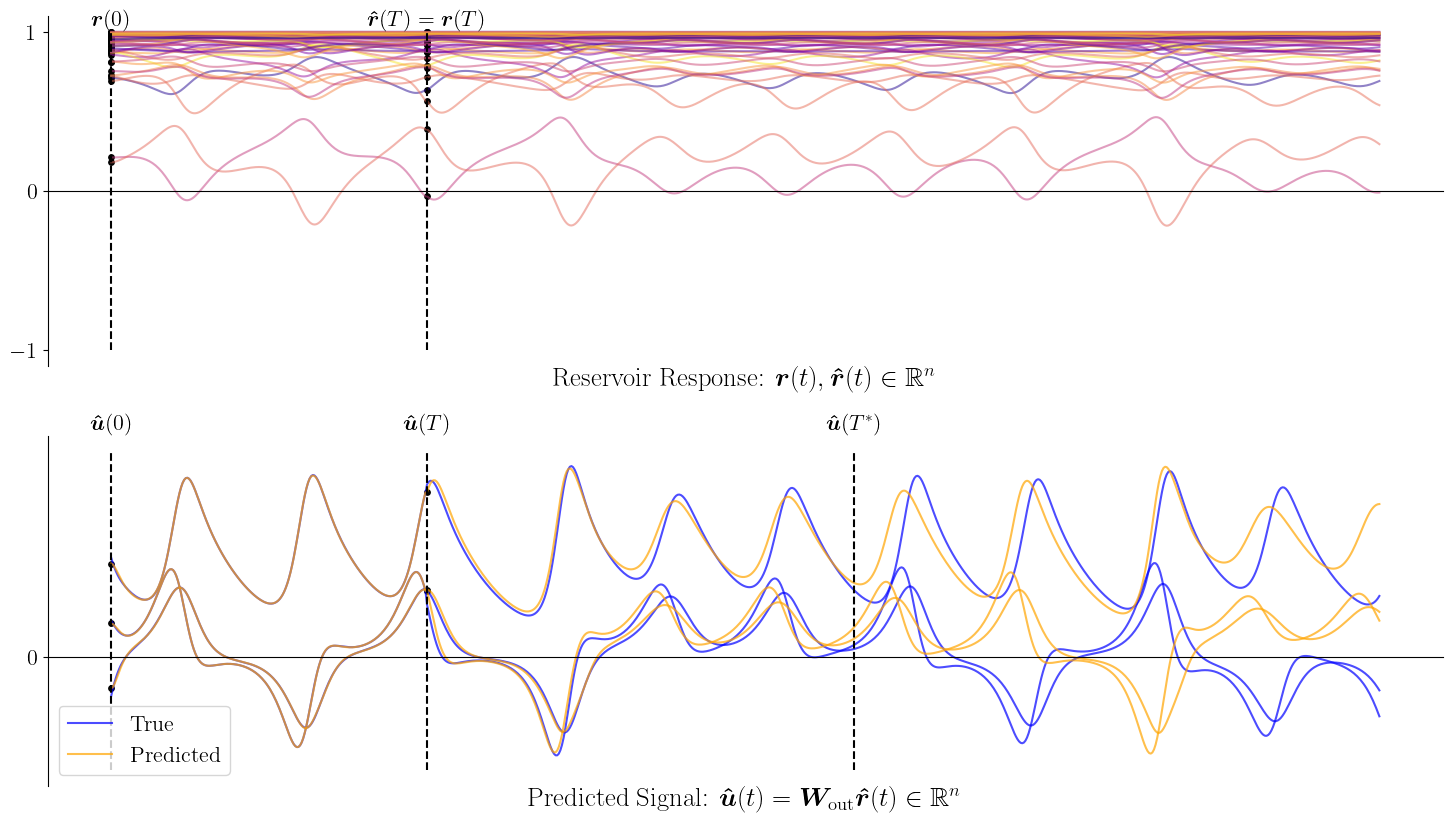

2.6900000000000004


In [238]:
norm = Normalize(vmin=min(initial_conditions), vmax=max(initial_conditions))
cmap = plt.get_cmap('plasma')

fig, axes = plt.subplots(2, 1, figsize=(18,10))

ax1 = axes[0]
for r, r0 in zip(reservoir_states.T, initial_conditions):
    ax1.plot(t, r, color=cmap(norm(r0)), alpha=0.5)


ax1.vlines(x=0, ymin=-1, ymax=1, color="black", linestyles="--")
ax1.scatter(np.zeros(n), reservoir_states[0], c="black", s=15)
ax1.annotate(
    r"$\bm{r}(0)$",
    xy=(0, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

ax1.vlines(x=T, ymin=-1, ymax=1, color="black", linestyles="--")
ax1.scatter(np.ones(n)*T, reservoir_states[T], c="black", s=15)
ax1.annotate(
    r"$\bm{\hat r}(T) = \bm{r}(T)$",
    xy=(T, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

ax1.set_yticks([-1,0,1])
ax1.set_xticks([])

ax1.spines['bottom'].set_position(('data', 0))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_title(r"Reservoir Response: $\bm{r}(t), \bm{\hat r}(t) \in \mathbb{R}^n$", y=-0.08)

ax2 = axes[1]

for i, u in enumerate(u_true.T):
    if i == 0:
        ax2.plot(t, u, color="blue", label="True", alpha=0.7)
    else:
        ax2.plot(t, u, color="blue", alpha=0.7)

for i, u in enumerate(u_hat.T):
    if i == 0:
        ax2.plot(t, u, color="orange", label="Predicted", alpha=0.7)
    else:
        ax2.plot(t, u, color="orange", alpha=0.7)

signal_bottom = ax2.get_ylim()[0]
signal_top = ax2.get_ylim()[1]

ax2.vlines(x=0, ymin=signal_bottom, ymax=signal_top, color="black", linestyles="--")
ax2.scatter(np.zeros(3), u_hat[0], c="black", s=15)
ax2.annotate(
    r"$\bm{\hat u}(0)$",
    xy=(0, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

ax2.vlines(x=T, ymin=signal_bottom, ymax=signal_top, color="black", linestyles="--")
ax2.scatter(np.ones(3)*T, u_hat[T], c="black", s=15)
ax2.annotate(
    r"$\bm{\hat u}(T)$",
    xy=(T, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

vpt_x = vpt*100 + T
ax2.vlines(x=(vpt_x), ymin=signal_bottom, ymax=signal_top, color="black", linestyles="--")
ax2.annotate(
    r"$\bm{\hat u}(T^*)$",
    xy=(vpt_x, plt.gca().get_ylim()[1]), # Top of the current y-limit
    xytext=(0, 0),
    textcoords="offset points",
    ha='center',
    va='bottom'
)

ax2.set_yticks([0])
ax2.set_xticks([])

ax2.spines['bottom'].set_position(('data', 0))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title(r"Predicted Signal: $\bm{\hat u}(t) = \bm{W}_{\text{out}} \bm{\hat r} (t) \in \mathbb{R}^n$", y=-0.08)


plt.legend()
plt.show()
print(vpt)

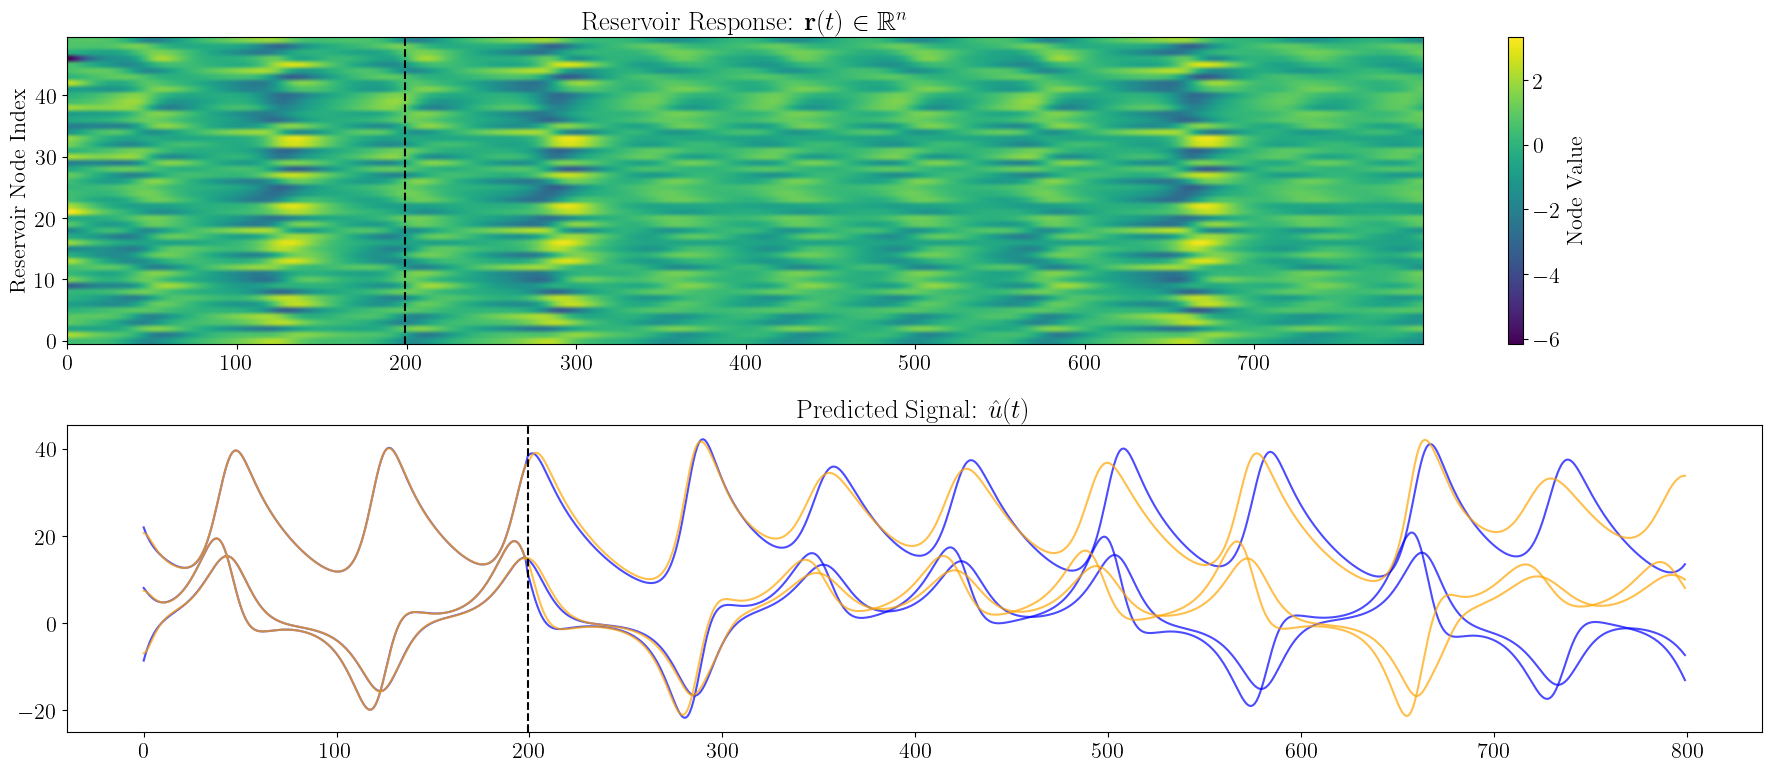

In [239]:
fig, axes = plt.subplots(2,1, figsize=(18,8))

# --- Reservoir state heatmap ---
ax1 = axes[0]

R = reservoir_states
Rnorm = (R - R.mean(axis=0)) / R.std(axis=0)

im = ax1.imshow(Rnorm.T, aspect="auto", origin="lower")

ax1.axvline(0, color="black", linestyle="--")
ax1.axvline(T, color="black", linestyle="--")

ax1.set_ylabel("Reservoir Node Index")
ax1.set_title(r"Reservoir Response: $\mathbf{r}(t) \in \mathbb{R}^n$")

cbar = plt.colorbar(im, ax=ax1)
cbar.set_label("Node Value")

# --- Signal plot ---
ax2 = axes[1]

for i,u in enumerate(u_true.T):
    ax2.plot(t, u, color="blue", alpha=0.7)

for i,u in enumerate(u_hat.T):
    ax2.plot(t, u, color="orange", alpha=0.7)

ax2.axvline(T, color="black", linestyle="--")

ax2.set_title(r"Predicted Signal: $\hat{u}(t)$")

plt.tight_layout()
plt.show()

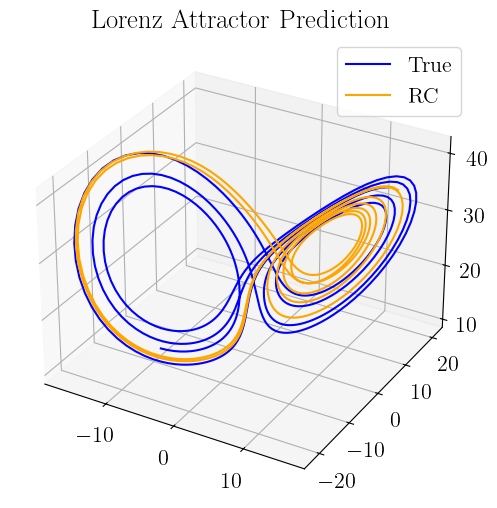

In [240]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection="3d")

ax.plot(*U_test.T, color="blue", label="True")
ax.plot(*U_hat_pred.T, color="orange", label="RC")

ax.set_title("Lorenz Attractor Prediction")
plt.legend()